### Gamma & Beta Distributions Parameter Define

In [26]:
import numpy as np
from scipy.stats import gaussian_kde
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde, rankdata

In [27]:
ga = 3
gb = 5

ba = 5
bb = 7

In [28]:
gamma_skewness = 2/np.sqrt(ga)

def beta_skewness_cal(alpha, beta):
    num = 2 * (beta - alpha) * np.sqrt(alpha + beta + 1)
    den = (alpha + beta + 2) * np.sqrt(alpha * beta)
    return num / den

beta_skewness = beta_skewness_cal(ba, bb)


In [29]:
print("True Skewness of Gamma(3, 5): ", gamma_skewness, "True Skewness of Beta(5, 7): ", beta_skewness)

True Skewness of Gamma(3, 5):  1.1547005383792517 True Skewness of Beta(5, 7):  0.17412840006286973


In [30]:
#Sample size:
n = 20, 50, 100, 200, 500, 1000, 2000, 5000

### Two Method of Asymmetry Testing

 #### Adjusted Fisher-Pearson coefficient of skewness <br>
 Existing function in pakcage: <b>stats.skew(data, bias=False)</b>


#### Correlation-based asymmetry measure
The correlation-based asymmetry measure is defined as:

$$
\eta(X) = -\operatorname{Corr}(f(X), F(X))
$$

where:

- $X$ is a random variable sampled from the target distribution.
- $f(X)$ is the probability density function (PDF) evaluated at $X$.
- $F(X)$ is the cumulative distribution function (CDF) evaluated at $X$.
- $\operatorname{Corr}(\cdot,\cdot)$ represents the Pearson correlation coefficient.

The value of $\eta(X)$ lies in the range:

$$
-1 \leq \eta(X) \leq 1
$$

Interpretation:

- $\eta(X) = 0$: symmetric distribution
- $\eta(X) > 0$: positively asymmetric distribution
- $\eta(X) < 0$: negatively asymmetric distribution
- $|\eta(X)|$ closer to 1: stronger asymmetry

In [31]:
def asymmetry_eta(x, bandwidth=None):
    """
    Method 2:
    eta_hat = -Corr(f_hat(X_i), F_hat(X_i))

    f_hat(X_i): leave-one-out Gaussian KDE
    F_hat(X_i): leave-one-out empirical CDF
    """

    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = len(x)

    if n < 3:
        return np.nan

    # Silverman's bandwidth
    s = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr / 1.349) if iqr > 0 else s

    if np.isclose(sigma, 0):
        sigma = s if s > 0 else 1.0

    h = bandwidth if bandwidth is not None else 0.9 * sigma * (n ** (-1 / 5))

    if h <= 0:
        h = 1.06 * (s if s > 0 else 1.0) * (n ** (-1 / 5))

    # Leave-one-out KDE: f_hat(X_i)
    diffs = (x[:, None] - x[None, :]) / h
    K = stats.norm.pdf(diffs)
    np.fill_diagonal(K, 0.0)
    f_hat = K.sum(axis=1) / ((n - 1) * h)

    # Leave-one-out empirical CDF: F_hat(X_i)
    indicators = (x[None, :] < x[:, None]).astype(float)
    np.fill_diagonal(indicators, 0.0)
    F_hat = indicators.sum(axis=1) / (n - 1)

    # eta = -Corr(f_hat, F_hat)
    if np.std(f_hat, ddof=1) == 0 or np.std(F_hat, ddof=1) == 0:
        return np.nan

    eta = -np.corrcoef(f_hat, F_hat)[0, 1]

    return eta

### List to save the average value of calculated skewness value

In [32]:
Method1_Gamma=[]
Method1_Beta=[]
Method2_Gamma=[]
Method2_Beta=[]

### N=20

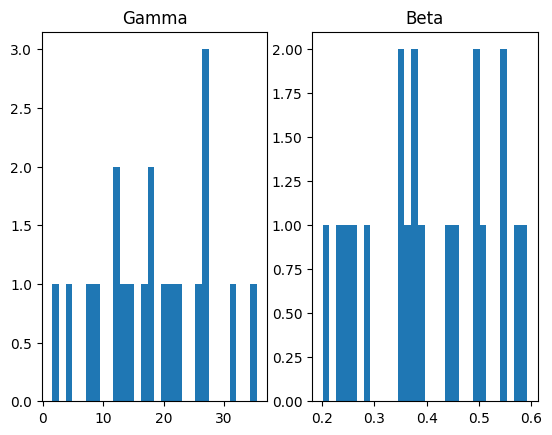

In [33]:
gdata20 = np.random.gamma(shape=ga, scale=gb, size = n[0] )
bdata20 = np.random.beta(a=ba,b=bb, size=n[0])
fig, axes = plt.subplots(1, 2)

axes[0].hist(gdata20, bins=30)
axes[0].set_title("Gamma")

axes[1].hist(bdata20, bins=30)
axes[1].set_title("Beta")

plt.show()

Gamma

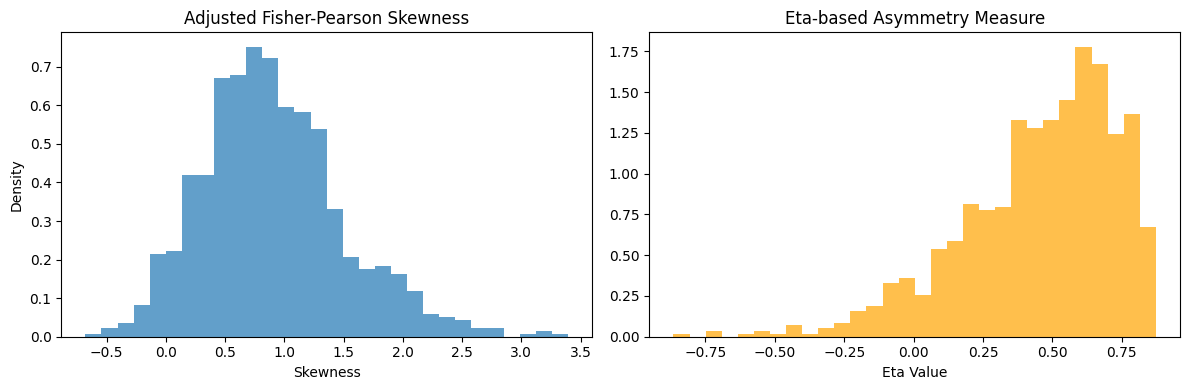

Method 1 Mean: 0.9016
Method 2 Mean: 0.4518


In [34]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[0])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

Beta

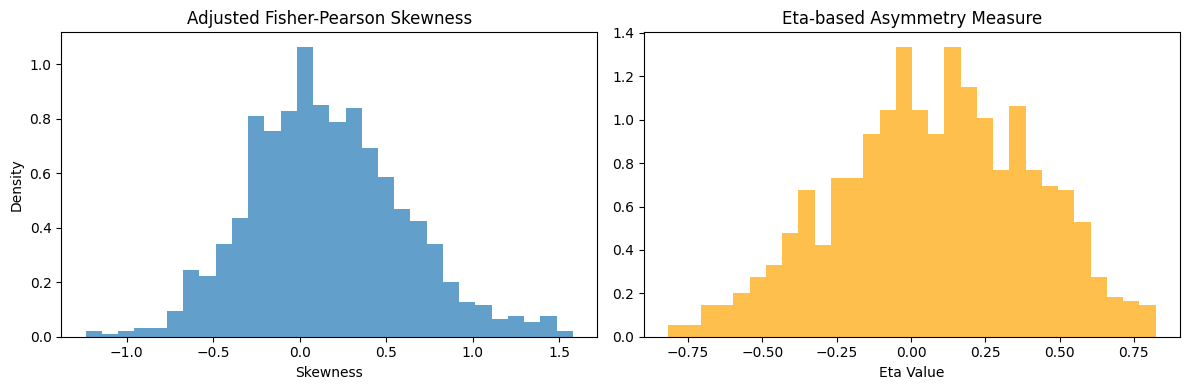

Method 1 Mean: 0.1561
Method 2 Mean: 0.0782


In [35]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[0])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

### N=50

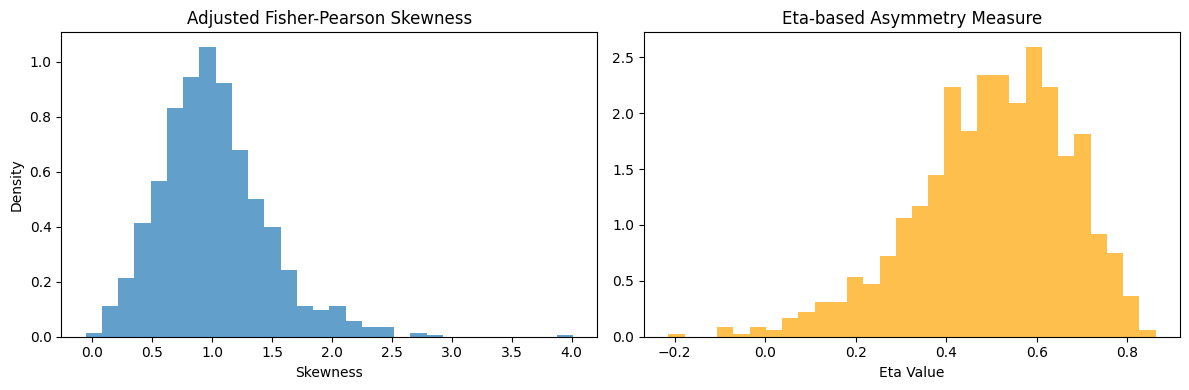

Method 1 Mean: 1.0116
Method 2 Mean: 0.4996


In [36]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[1])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

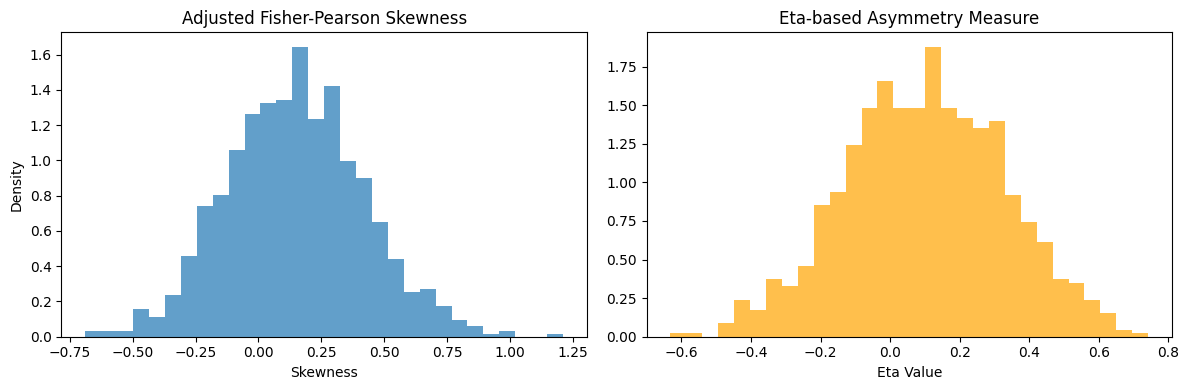

Method 1 Mean: 0.1470
Method 2 Mean: 0.0987


In [37]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[1])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

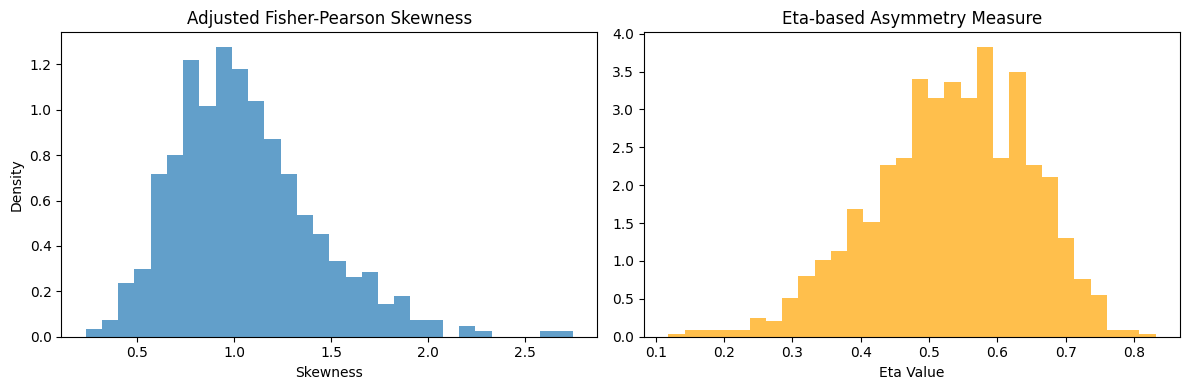

Method 1 Mean: 1.0571
Method 2 Mean: 0.5317


In [38]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[2])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

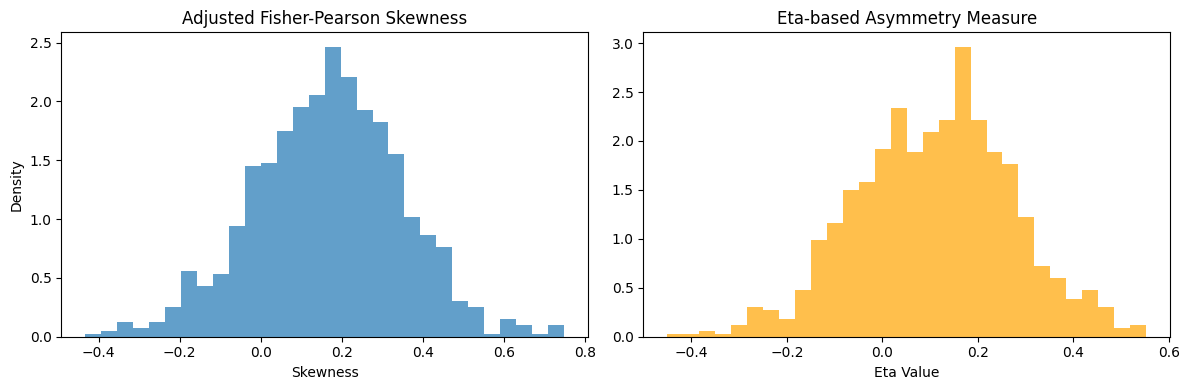

Method 1 Mean: 0.1672
Method 2 Mean: 0.1099


In [39]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[2])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

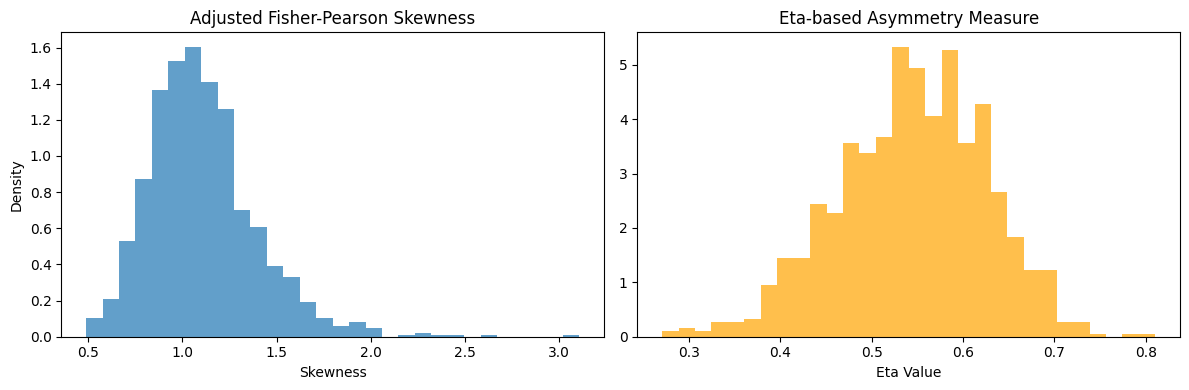

Method 1 Mean: 1.1095
Method 2 Mean: 0.5445


In [40]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[3])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

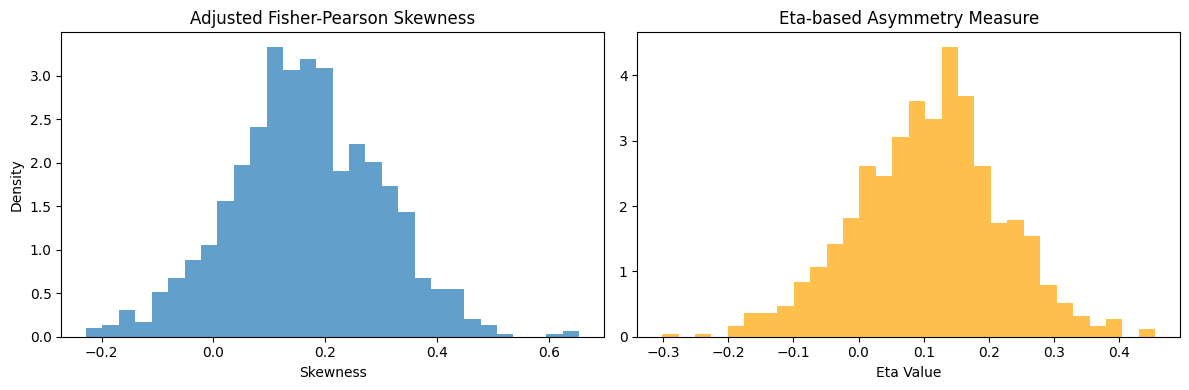

Method 1 Mean: 0.1649
Method 2 Mean: 0.1082


In [41]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[3])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

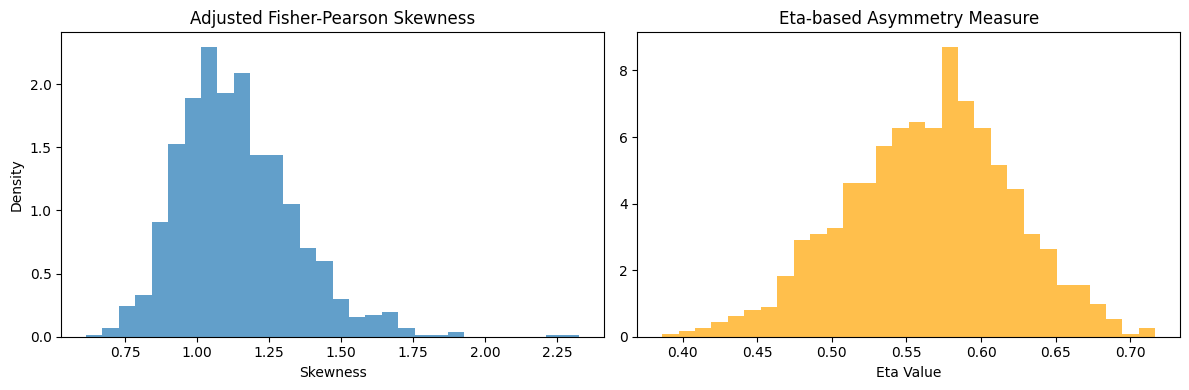

Method 1 Mean: 1.1371
Method 2 Mean: 0.5645


In [42]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[4])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

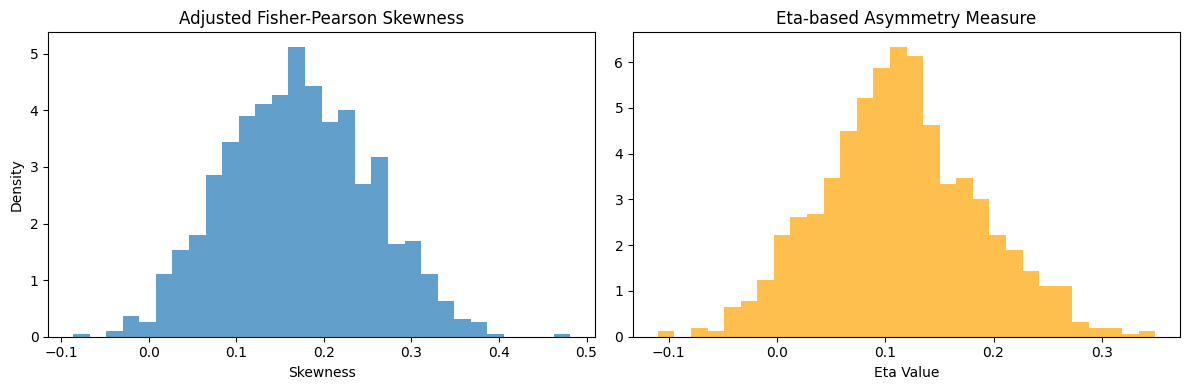

Method 1 Mean: 0.1704
Method 2 Mean: 0.1139


In [43]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[4])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

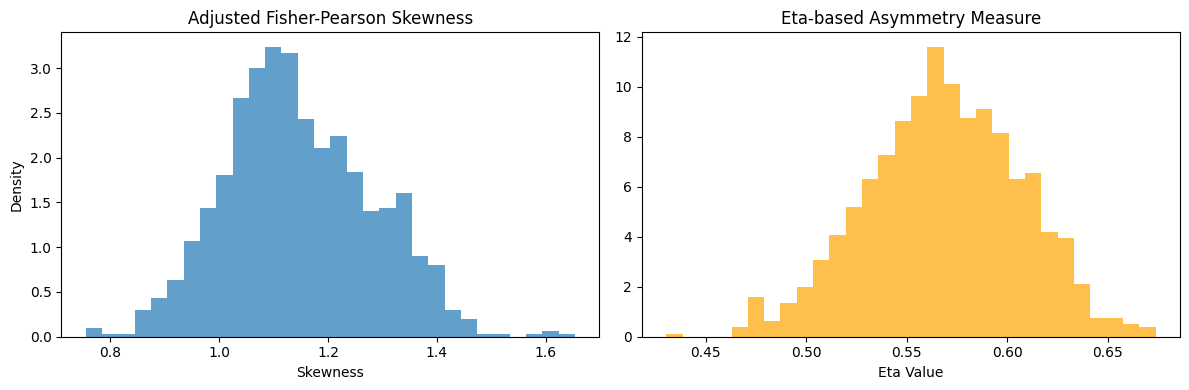

Method 1 Mean: 1.1473
Method 2 Mean: 0.5682


In [44]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[5])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

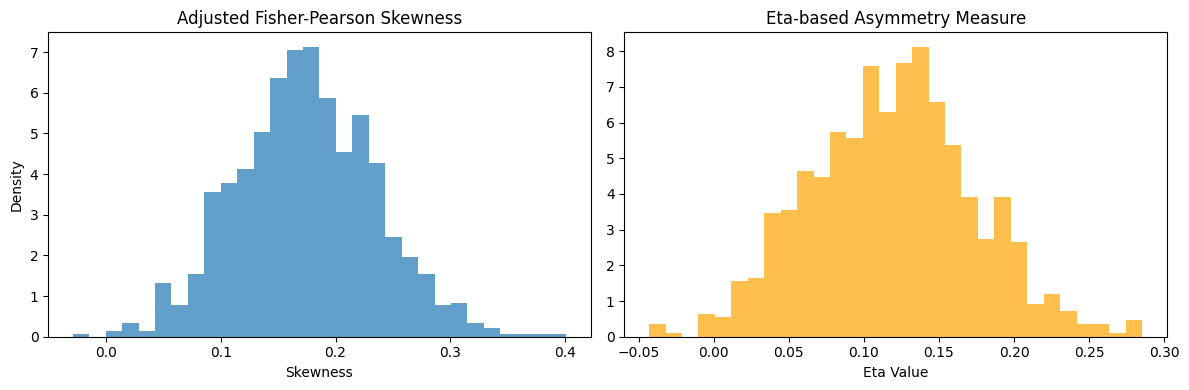

Method 1 Mean: 0.1744
Method 2 Mean: 0.1188


In [45]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[5])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

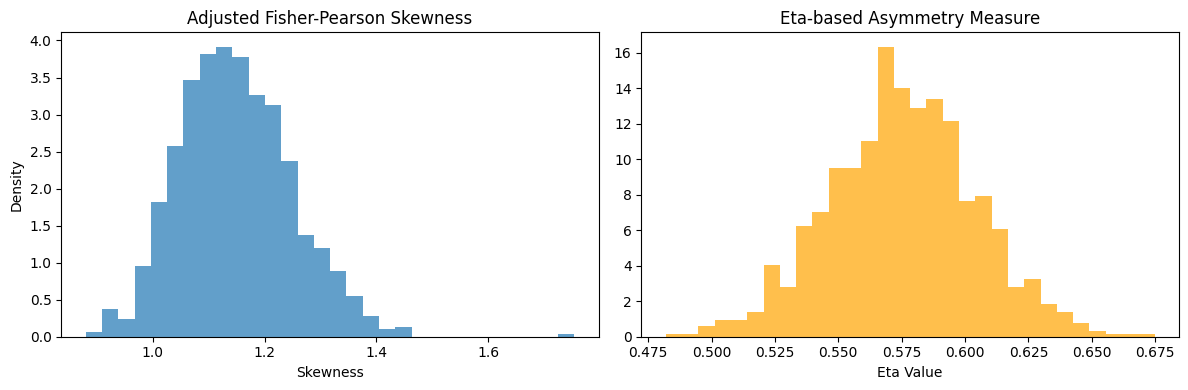

Method 1 Mean: 1.1487
Method 2 Mean: 0.5754


In [46]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[6])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

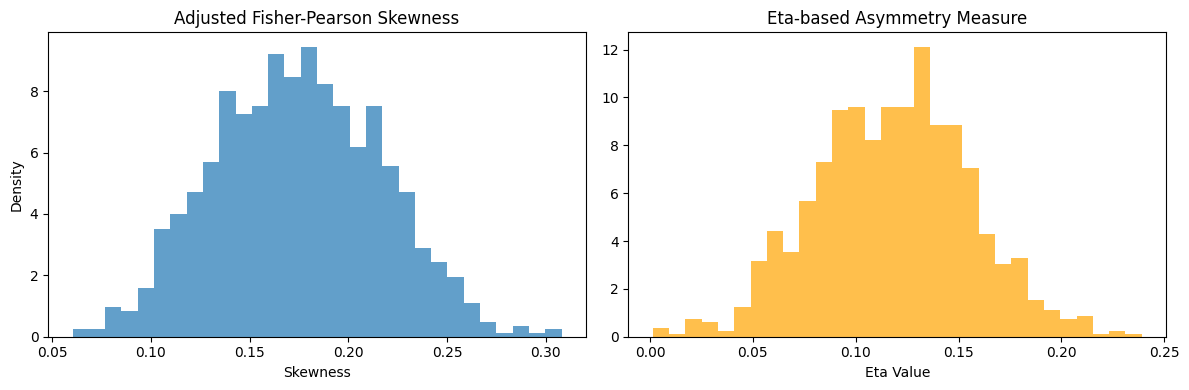

Method 1 Mean: 0.1746
Method 2 Mean: 0.1179


In [47]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[6])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

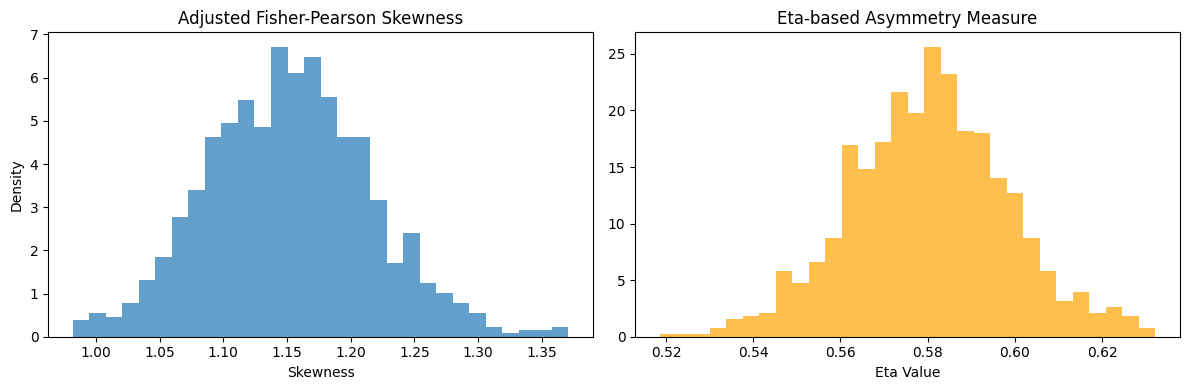

Method 1 Mean: 1.1521
Method 2 Mean: 0.5803


In [48]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.gamma(shape=ga, scale=gb, size=n[7])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Gamma.append(mean1)
Method2_Gamma.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

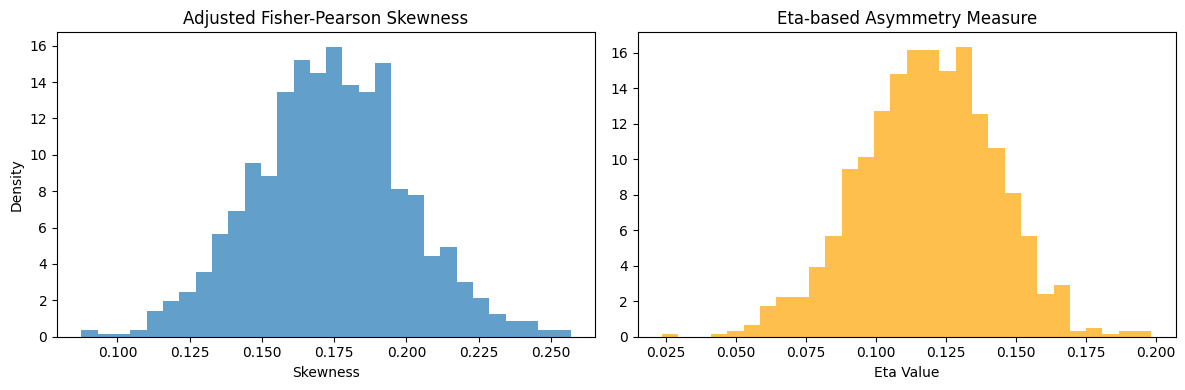

Method 1 Mean: 0.1736
Method 2 Mean: 0.1184


In [49]:
repeats = 1000
skew_method1 = []
skew_method2 = []
for i in range(repeats):
    data = np.random.beta(a=ba, b=bb, size=n[7])

    s1 = stats.skew(data, bias=False)
    s2 = asymmetry_eta(data)

    if not np.isnan(s1):
        skew_method1.append(s1)
    if not np.isnan(s2):
        skew_method2.append(s2)


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1
axes[0].hist(skew_method1, bins=30, density=True, alpha=0.7)
axes[0].set_title("Adjusted Fisher-Pearson Skewness")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Density")

# Method 2
axes[1].hist(skew_method2, bins=30, density=True, alpha=0.7, color='orange')
axes[1].set_title("Eta-based Asymmetry Measure")
axes[1].set_xlabel("Eta Value")

plt.tight_layout()
plt.show()

mean1 = np.mean(skew_method1)
mean2 = np.mean(skew_method2)
Method1_Beta.append(mean1)
Method2_Beta.append(mean2)
print(f"Method 1 Mean: {mean1:.4f}")
print(f"Method 2 Mean: {mean2:.4f}")

In [50]:

Method1_Gamma = np.array(Method1_Gamma, dtype=float)
Method1_Beta  = np.array(Method1_Beta, dtype=float)
Method2_Gamma = np.array(Method2_Gamma, dtype=float)
Method2_Beta  = np.array(Method2_Beta, dtype=float)

sample_sizes = [20, 50, 100, 200, 500, 1000, 2000, 5000]

# true values
true_gamma = 1.1547005383792517
true_beta  = 0.17412840006286973

df = pd.DataFrame({
    "n": sample_sizes,
    "M1_Gamma": Method1_Gamma,
    "M2_Gamma": Method2_Gamma,
    "M1_Beta": Method1_Beta,
    "M2_Beta": Method2_Beta
})

df["Bias_M1_Gamma"] = df["M1_Gamma"] - true_gamma
df["Bias_M2_Gamma"] = df["M2_Gamma"] - true_gamma
df["Bias_M1_Beta"]  = df["M1_Beta"]  - true_beta
df["Bias_M2_Beta"]  = df["M2_Beta"]  - true_beta

print(df.round(4))

      n  M1_Gamma  M2_Gamma  M1_Beta  M2_Beta  Bias_M1_Gamma  Bias_M2_Gamma  \
0    20    0.9016    0.4518   0.1561   0.0782        -0.2531        -0.7029   
1    50    1.0116    0.4996   0.1470   0.0987        -0.1431        -0.6551   
2   100    1.0571    0.5317   0.1672   0.1099        -0.0976        -0.6230   
3   200    1.1095    0.5445   0.1649   0.1082        -0.0452        -0.6102   
4   500    1.1371    0.5645   0.1704   0.1139        -0.0176        -0.5902   
5  1000    1.1473    0.5682   0.1744   0.1188        -0.0074        -0.5865   
6  2000    1.1487    0.5754   0.1746   0.1179        -0.0060        -0.5793   
7  5000    1.1521    0.5803   0.1736   0.1184        -0.0026        -0.5744   

   Bias_M1_Beta  Bias_M2_Beta  
0       -0.0181       -0.0959  
1       -0.0271       -0.0755  
2       -0.0069       -0.0642  
3       -0.0092       -0.0660  
4       -0.0038       -0.0602  
5        0.0003       -0.0553  
6        0.0004       -0.0562  
7       -0.0005       -0.0558  


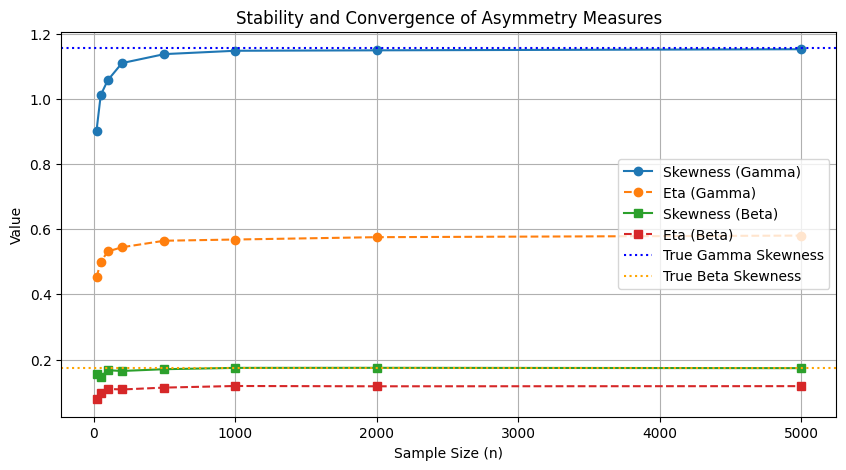

In [51]:
plt.figure(figsize=(10,5))

plt.plot(sample_sizes, Method1_Gamma, marker='o', label='Skewness (Gamma)', linestyle='-')
plt.plot(sample_sizes, Method2_Gamma, marker='o', label='Eta (Gamma)', linestyle='--')

plt.plot(sample_sizes, Method1_Beta, marker='s', label='Skewness (Beta)', linestyle='-')
plt.plot(sample_sizes, Method2_Beta, marker='s', label='Eta (Beta)', linestyle='--')

plt.axhline(true_gamma, color='blue', linestyle=':', label='True Gamma Skewness')
plt.axhline(true_beta, color='orange', linestyle=':', label='True Beta Skewness')

plt.xlabel("Sample Size (n)")
plt.ylabel("Value")
plt.title("Stability and Convergence of Asymmetry Measures")
plt.legend()
plt.grid(True)
plt.show()